In [2]:
!nvidia-smi

Mon Feb 12 02:29:40 2024       
+---------------------------------------------------------------------------------------+
| NVIDIA-SMI 535.154.05             Driver Version: 535.154.05   CUDA Version: 12.2     |
|-----------------------------------------+----------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |         Memory-Usage | GPU-Util  Compute M. |
|                                         |                      |               MIG M. |
|=========================================+======================+======================|
|   0  NVIDIA GeForce GTX 1650        Off | 00000000:01:00.0 Off |                  N/A |
| N/A   52C    P0               6W /  50W |      6MiB /  4096MiB |      0%      Default |
|                                         |                      |                  N/A |
+-----------------------------------------+----------------------+--

In [3]:
!pip install transformers


Defaulting to user installation because normal site-packages is not writeable


In [4]:
import os 
import pandas as pd 
import numpy as np 
import shutil 
import sys 
import tqdm.notebook as tq 
from collections import defaultdict 
import torch 
import torch.nn as nn 
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
# device = torch.device('cpu')

In [5]:
data_dir = "train_data_preprocessed.csv"
df= pd.read_csv(data_dir)

In [6]:
df.head()

,content,unnecessary,mandatory,pharma,conspiracy,political,country,rushed,ingredients,side-effect,ineffective,religious,none,corrected_text,text_without_stopwords,text_lemmatized,text_without_stopwords_freq
0,imaerell BradfatherSpeak ALEXNEWMAN JOU Newsfl...,1,0,0,0,0,0,0,0,1,0,0,0,imaerell bradfatherspeak alexnewman you newsfl...,imaerell bradfatherspeak alexnewman newsflash ...,imaerell bradfatherspeak alexnewman newsflash ...,imaerell bradfatherspeak alexnewman newsflash ...
1,theousherwood LBC I am not anti vaccine but lo...,0,0,1,0,0,0,0,0,0,0,0,0,theousherwood lac i am not anti vaccine but lo...,theousherwood lac anti vaccine looking company...,theousherwood lac anti vaccine look company pf...,theousherwood lac anti look company produce re...
2,BorisJohnson I will not be taking any vaccine ...,0,0,0,0,0,0,0,0,0,0,0,1,borisjohnson i will not be taking any vaccine ...,borisjohnson taking vaccine ever get controlof...,borisjohnson take vaccine ever get controlofdi...,borisjohnson ever controlofdiseaseact1984 update
3,LPerrins They have set this up that nothing wi...,0,0,0,0,0,0,0,0,0,1,0,0,lperrins they have set this up that nothing wi...,lperrins set nothing ever opened properly new ...,lperrins set nothing ever open properly new va...,lperrins set nothing ever open properly new va...
4,AngelaDeAngelo I believe I read it on one of P...,0,0,0,0,0,0,1,0,0,0,0,0,angeladeangelo i believe i read it on one of p...,angeladeangelo believe read one pfizers partne...,angeladeangelo believe read one pfizers partne...,angeladeangelo believe read pfizers partner si...


In [7]:
df_data = df[['text_without_stopwords_freq','unnecessary','mandatory','pharma','conspiracy','political','country','rushed','ingredients','side-effect','ineffective','religious','none']]

In [8]:
df_data = df_data.rename(columns={'text_without_stopwords_freq': 'concern'})


In [9]:
df_data

,concern,unnecessary,mandatory,pharma,conspiracy,political,country,rushed,ingredients,side-effect,ineffective,religious,none
0,imaerell bradfatherspeak alexnewman newsflash ...,1,0,0,0,0,0,0,0,1,0,0,0
1,theousherwood lac anti look company produce re...,0,0,1,0,0,0,0,0,0,0,0,0
2,borisjohnson ever controlofdiseaseact1984 update,0,0,0,0,0,0,0,0,0,0,0,1
3,lperrins set nothing ever open properly new va...,0,0,0,0,0,0,0,0,0,1,0,0
4,angeladeangelo believe read pfizers partner si...,0,0,0,0,0,0,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6848,need another unknown illness manufacture accid...,0,0,0,0,0,0,0,0,1,0,0,0
6849,zagamamas wary astrazenica oxford trial 28 yea...,0,0,0,0,0,0,1,0,0,0,0,0
6850,geoohhm laugh loud mean really depend mean opp...,1,0,0,0,0,0,0,0,0,0,0,0
6851,canaditude seriously care think mandatory wrong,0,1,0,0,0,0,0,0,0,0,0,0


In [10]:
from sklearn.model_selection import train_test_split
df_train, df_test = train_test_split(df_data, random_state=77, test_size=0.30, shuffle=True)
df_test, df_valid = train_test_split(df_test, random_state=88, test_size=0.50, shuffle=True)

In [11]:
print(f"Train: {df_train.shape}, Test: {df_test.shape}, Valid: {df_valid.shape}")

Train: (4797, 13), Test: (1028, 13), Valid: (1028, 13)


In [12]:
# Hyperparameters
MAX_LEN = 256
TRAIN_BATCH_SIZE = 8
VALID_BATCH_SIZE = 8
TEST_BATCH_SIZE = 8
EPOCHS = 5
LEARNING_RATE = 2e-05
THRESHOLD = 0.5 # threshold for the sigmoid

In [13]:
from transformers import BertTokenizer, BertModel

In [14]:
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

In [15]:
# Test the tokenizer
test_text = "We are testing BERT tokenizer."
# generate encodings
encodings = tokenizer.encode_plus(test_text, 
                                  add_special_tokens = True,
                                  max_length = 50,
                                  truncation = True,
                                  padding = "max_length", 
                                  return_attention_mask = True, 
                                  return_tensors = "pt")
# we get a dictionary with three keys (see: https://huggingface.co/transformers/glossary.html) 
encodings

{'input_ids': tensor([[  101,  2057,  2024,  5604, 14324, 19204, 17629,  1012,   102,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0]]), 'token_type_ids': tensor([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0]])}

In [16]:
df_train['concern']

701     global elite establishment hype non existent p...
1949    zzjazzy sidneypowell1 arc nbc msnbc stay away ...
3895    tea launch investigation eight australian diag...
3915    runnerosborn realize cannot give informed cons...
2103                  alexberenson kid even approve adult
                              ...                        
1317    kinsellawarren even link back tune may work el...
2283    clareoneill207 cavman76 valkyearie20201 hope t...
2004    borisjohnson cannot actually save others even ...
3668    suck immune system boost need give halfassed v...
607     break news surprising though urge pause use jo...
Name: concern, Length: 4797, dtype: object

In [17]:
class CustomDataset(torch.utils.data.Dataset):
    def __init__(self, df, tokenizer, max_len, target_list):
        self.tokenizer = tokenizer
        self.df = df
        self.title = list(df['concern'])
        self.targets = self.df[target_list].values
        self.max_len = max_len

    def __len__(self):
        return len(self.title)

    def __getitem__(self, index):
        title = str(self.title[index])
        title = " ".join(title.split())
        inputs = self.tokenizer.encode_plus(
            title,
            None,
            add_special_tokens=True,
            max_length=self.max_len,
            padding='max_length',
            return_token_type_ids=True,
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt'
        )
        return {
            'input_ids': inputs['input_ids'].flatten(),
            'attention_mask': inputs['attention_mask'].flatten(),
            'token_type_ids': inputs["token_type_ids"].flatten(),
            'targets': torch.FloatTensor(self.targets[index]),
            'title': title
        }

In [18]:
target_list = list(df_data.columns)
target_list

['concern',
 'unnecessary',
 'mandatory',
 'pharma',
 'conspiracy',
 'political',
 'country',
 'rushed',
 'ingredients',
 'side-effect',
 'ineffective',
 'religious',
 'none']

In [19]:
target_list = target_list[1:]

In [20]:
target_list

['unnecessary',
 'mandatory',
 'pharma',
 'conspiracy',
 'political',
 'country',
 'rushed',
 'ingredients',
 'side-effect',
 'ineffective',
 'religious',
 'none']

In [21]:
train_dataset = CustomDataset(df_train, tokenizer, MAX_LEN, target_list)
valid_dataset = CustomDataset(df_valid, tokenizer, MAX_LEN, target_list)
test_dataset = CustomDataset(df_test, tokenizer, MAX_LEN, target_list)

In [22]:
# testing the dataset
next(iter(train_dataset))

{'input_ids': tensor([  101,  3795,  7069,  5069,  1044, 18863,  2512, 25953,  6090,  3207,
          7712, 28616,  8557,  3571,  3443,  2185,  3265,  4071,  6135,  2491,
          2644, 10214, 10915,  2522, 17258, 16147, 12436, 14693,  9323,  3021,
          5867,  2015,  7499,  4071,  3659,   102,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,   

In [23]:
# Data loaders
train_data_loader = torch.utils.data.DataLoader(train_dataset, 
    batch_size=TRAIN_BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

val_data_loader = torch.utils.data.DataLoader(valid_dataset, 
    batch_size=VALID_BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

test_data_loader = torch.utils.data.DataLoader(test_dataset, 
    batch_size=TEST_BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

In [29]:
class BERTClass(torch.nn.Module):
    def __init__(self):
        super(BERTClass, self).__init__()
        self.bert_model = BertModel.from_pretrained('bert-base-uncased', return_dict=True)
        self.dropout = torch.nn.Dropout(0.3)
        self.linear = torch.nn.Linear(768, 12)

    def forward(self, input_ids, attn_mask, token_type_ids):
        output = self.bert_model(
            input_ids, 
            attention_mask=attn_mask, 
            token_type_ids=token_type_ids
        )
        output_dropout = self.dropout(output.pooler_output)
        output = self.linear(output_dropout)
        return output

model = BERTClass()

# # Freezing BERT layers: (tested, weaker convergence)
# for param in model.bert_model.parameters():
#     param.requires_grad = False

model.to(device)

BERTClass(
  (bert_model): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_a

In [30]:
# BCEWithLogitsLoss combines a Sigmoid layer and the BCELoss in one single class. 
# This version is more numerically stable than using a plain Sigmoid followed 
# by a BCELoss as, by combining the operations into one layer, 
# we take advantage of the log-sum-exp trick for numerical stability.
def loss_fn(outputs, targets):
    return torch.nn.BCEWithLogitsLoss()(outputs, targets)

In [31]:
from transformers import AdamW

# define the optimizer
optimizer = AdamW(model.parameters(), lr = 2e-5)         

/home/aayush/.local/lib/python3.10/site-packages/transformers/optimization.py:429: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(


In [32]:
# Training of the model for one epoch
def train_model(training_loader, model, optimizer):

    losses = []
    correct_predictions = 0
    num_samples = 0
    # set model to training mode (activate droput, batch norm)
    model.train()
    # initialize the progress bar
    loop = tq.tqdm(enumerate(training_loader), total=len(training_loader), 
                      leave=True, colour='steelblue')
    for batch_idx, data in loop:
        ids = data['input_ids'].to(device, dtype = torch.long)
        mask = data['attention_mask'].to(device, dtype = torch.long)
        token_type_ids = data['token_type_ids'].to(device, dtype = torch.long)
        targets = data['targets'].to(device, dtype = torch.float)

        # forward
        outputs = model(ids, mask, token_type_ids) # (batch,predict)=(32,8)
        loss = loss_fn(outputs, targets)
        losses.append(loss.item())
        # training accuracy, apply sigmoid, round (apply thresh 0.5)
        outputs = torch.sigmoid(outputs).cpu().detach().numpy().round()
        targets = targets.cpu().detach().numpy()
        correct_predictions += np.sum(outputs==targets)
        num_samples += targets.size   # total number of elements in the 2D array

        # backward
        optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        # grad descent step
        optimizer.step()

        # Update progress bar
        #loop.set_description(f"")
        #loop.set_postfix(batch_loss=loss)

    # returning: trained model, model accuracy, mean loss
    return model, float(correct_predictions)/num_samples, np.mean(losses)

In [33]:
def eval_model(validation_loader, model, optimizer):
    losses = []
    correct_predictions = 0
    num_samples = 0
    # set model to eval mode (turn off dropout, fix batch norm)
    model.eval()

    with torch.no_grad():
        for batch_idx, data in enumerate(validation_loader, 0):
            ids = data['input_ids'].to(device, dtype = torch.long)
            mask = data['attention_mask'].to(device, dtype = torch.long)
            token_type_ids = data['token_type_ids'].to(device, dtype = torch.long)
            targets = data['targets'].to(device, dtype = torch.float)
            outputs = model(ids, mask, token_type_ids)

            loss = loss_fn(outputs, targets)
            losses.append(loss.item())

            # validation accuracy
            # add sigmoid, for the training sigmoid is in BCEWithLogitsLoss
            outputs = torch.sigmoid(outputs).cpu().detach().numpy().round()
            targets = targets.cpu().detach().numpy()
            correct_predictions += np.sum(outputs==targets)
            num_samples += targets.size   # total number of elements in the 2D array

    return float(correct_predictions)/num_samples, np.mean(losses)

In [28]:
history = defaultdict(list)
best_accuracy = 0
for epoch in range(1, EPOCHS+1):
    print(f'Epoch {epoch}/{EPOCHS}')
    model, train_acc, train_loss = train_model(train_data_loader, model, optimizer)
    val_acc, val_loss = eval_model(val_data_loader, model, optimizer)

    print(f'train_loss={train_loss:.4f}, val_loss={val_loss:.4f} train_acc={train_acc:.4f}, val_acc={val_acc:.4f}')

    history['train_acc'].append(train_acc)
    history['train_loss'].append(train_loss)
    history['val_acc'].append(val_acc)
    history['val_loss'].append(val_loss)
    
    # save the best model
    if val_acc > best_accuracy:
        torch.save(model.state_dict(), os.path.join("output","MLTC_model_state.bin"))
        best_accuracy = val_acc

Epoch 1/5


  0%|          | 0/600 [00:00<?, ?it/s]

train_loss=0.2866, val_loss=0.2420 train_acc=0.9041, val_acc=0.9200
Epoch 2/5


  0%|          | 0/600 [00:00<?, ?it/s]

train_loss=0.2182, val_loss=0.2049 train_acc=0.9259, val_acc=0.9266
Epoch 3/5


...

train_loss=0.1637, val_loss=0.1923 train_acc=0.9462, val_acc=0.9339
Epoch 4/5


  0%|          | 0/600 [00:00<?, ?it/s]

train_loss=0.1234, val_loss=0.1908 train_acc=0.9609, val_acc=0.9325
Epoch 5/5


  0%|          | 0/600 [00:00<?, ?it/s]

train_loss=0.0919, val_loss=0.2073 train_acc=0.9717, val_acc=0.9313


In [29]:
import matplotlib.pyplot as plt

/home/aayush/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


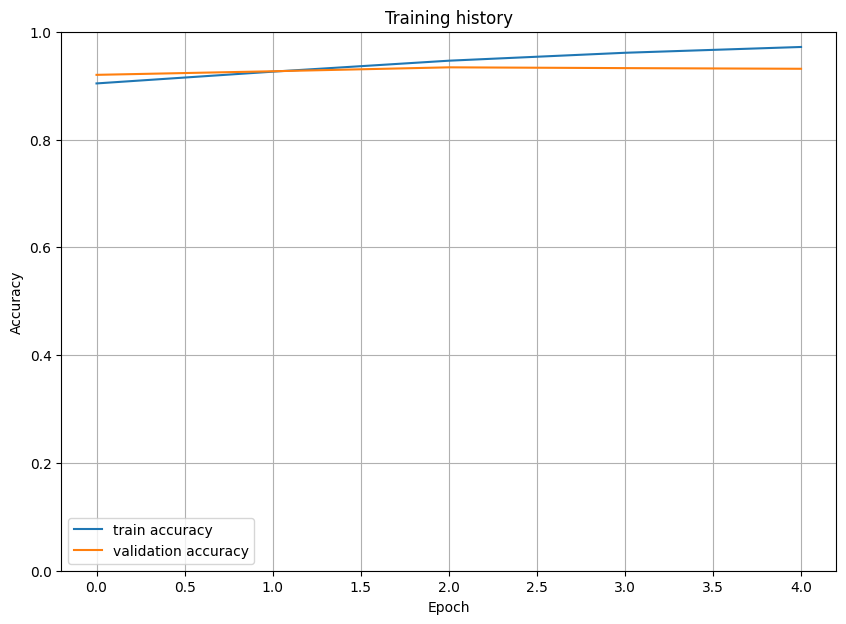

In [30]:
plt.rcParams["figure.figsize"] = (10,7)
plt.plot(history['train_acc'], label='train accuracy')
plt.plot(history['val_acc'], label='validation accuracy')
plt.title('Training history')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()
plt.ylim([0, 1]);
plt.grid()

In [34]:
df_train = df_data
train_dataset = CustomDataset(df_train, tokenizer, MAX_LEN, target_list)
history = defaultdict(list)
best_accuracy = 0
for epoch in range(1, EPOCHS+1):
    print(f'Epoch {epoch}/{EPOCHS}')
    model, train_acc, train_loss = train_model(train_data_loader, model, optimizer)

    print(f'train_loss={train_loss:.4f}, train_acc={train_acc:.4f}')

    history['train_acc'].append(train_acc)
    history['train_loss'].append(train_loss)
    if train_acc > best_accuracy:
        torch.save(model.state_dict(), os.path.join("output2","MLTC_model_state.bin"))
        best_accuracy = train_acc

Epoch 1/5


  0%|          | 0/600 [00:00<?, ?it/s]

train_loss=0.2811, train_acc=0.9055
Epoch 2/5


  0%|          | 0/600 [00:00<?, ?it/s]

train_loss=0.2074, train_acc=0.9295
Epoch 3/5


...

train_loss=0.1608, train_acc=0.9474
Epoch 4/5


  0%|          | 0/600 [00:00<?, ?it/s]

train_loss=0.1221, train_acc=0.9616
Epoch 5/5


  0%|          | 0/600 [00:00<?, ?it/s]

train_loss=0.0922, train_acc=0.9720
